# SSVEP EDA — Zhu et al. 2021 Wearable Dataset — DRY electrodes 



# 2. Dataset description

Zhu et al. (2021) wearable SSVEP dataset:

- **102 subjects**
- **12 SSVEP targets**
- **8 channels**: `POz, PO3, PO4, PO5, PO6, Oz, O1, O2`
- **10 blocks** for dry and 10 blocks for wet electrodes
- saved sampling rate: **250 Hz**
- one epoch: **2.84 s = 710 samples**
- file structure: `data.shape == (8, 710, 2, 10, 12)`

Dimensions:

```text
[channel, time, electrode_type, block, target_index]
```

## Critical target-index mapping

The official stimulation file gives this target order:

| target index | frequency [Hz] | phase [π] |
|---:|---:|---:|
| 1 | 9.25 | 0.0 |
| 2 | 11.25 | 0.0 |
| 3 | 13.25 | 0.0 |
| 4 | 9.75 | 0.5 |
| 5 | 11.75 | 0.5 |
| 6 | 13.75 | 0.5 |
| 7 | 10.25 | 1.0 |
| 8 | 12.25 | 1.0 |
| 9 | 14.25 | 1.0 |
| 10 | 10.75 | 1.5 |
| 11 | 12.75 | 1.5 |
| 12 | 14.75 | 1.5 |

Therefore the fifth axis of the `.mat` file must **not** be labelled with a simple
ascending frequency list.

Official files:
- `Readme.pdf`
- `stimulation_information.pdf`
- Zhu et al., Sensors 2021, 21, 1256.


# 3. Environment and configuration

In [5]:
import warnings
warnings.simplefilter("default")

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.io import loadmat
from scipy.signal import (
    welch,
    cheby1,
    cheb1ord,
    butter,
    sosfiltfilt,
)
from sklearn.cross_decomposition import CCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


## 3.2 Global constants

In [6]:
FS = 250

CHANNELS = ["POz", "PO3", "PO4", "PO5", "PO6", "Oz", "O1", "O2"]

TARGET_FREQS_BY_INDEX = np.array([
    9.25, 11.25, 13.25,
    9.75, 11.75, 13.75,
    10.25, 12.25, 14.25,
    10.75, 12.75, 14.75,
], dtype=float)

TARGET_PHASES_PI_BY_INDEX = np.array([
    0.0, 0.0, 0.0,
    0.5, 0.5, 0.5,
    1.0, 1.0, 1.0,
    1.5, 1.5, 1.5,
], dtype=float)

TARGET_PHASES_RAD_BY_INDEX = TARGET_PHASES_PI_BY_INDEX * np.pi

TARGET_FREQS_ALL = sorted(TARGET_FREQS_BY_INDEX.tolist())

DRY_ELECTRODE_INDEX = 0

PRE_STIM_SEC = 0.50
VISUAL_LATENCY_SEC = 0.14
STIM_DURATION_SEC = 2.00

# Analyse 2 s of response starting 140 ms after stimulus onset.
ANALYSIS_START_SEC = PRE_STIM_SEC + VISUAL_LATENCY_SEC
ANALYSIS_DURATION_SEC = STIM_DURATION_SEC
ANALYSIS_START_SAMPLE = int(round(ANALYSIS_START_SEC * FS))
ANALYSIS_END_SAMPLE = ANALYSIS_START_SAMPLE + int(round(ANALYSIS_DURATION_SEC * FS))

stimulus_mapping = pd.DataFrame({
    "target_index": np.arange(1, 13),
    "frequency_hz": TARGET_FREQS_BY_INDEX,
    "phase_pi": TARGET_PHASES_PI_BY_INDEX,
})

display(stimulus_mapping)

print("Sorted target frequencies:", TARGET_FREQS_ALL)
print("Channels:", CHANNELS)
print("Analysis samples:", ANALYSIS_START_SAMPLE, ":", ANALYSIS_END_SAMPLE)


,target_index,frequency_hz,phase_pi
0,1,9.25,0.0
1,2,11.25,0.0
2,3,13.25,0.0
3,4,9.75,0.5
4,5,11.75,0.5
5,6,13.75,0.5
6,7,10.25,1.0
7,8,12.25,1.0
8,9,14.25,1.0
9,10,10.75,1.5


Sorted target frequencies: [9.25, 9.75, 10.25, 10.75, 11.25, 11.75, 12.25, 12.75, 13.25, 13.75, 14.25, 14.75]
Channels: ['POz', 'PO3', 'PO4', 'PO5', 'PO6', 'Oz', 'O1', 'O2']
Analysis samples: 160 : 660


## 3.3 Analysis configuration

In [7]:
DATA_DIR = Path("./Zhu2021_Wearable_SSVEP")

# Evaluate every subject in the public dataset.
ALL_SUBJECTS = list(range(1, 103))

# Zhu2021 dry-electrode FBCCA settings.
N_HARMONICS = 5
FBCCA_N_SUBBANDS = 5
FBCCA_A = 2.0
FBCCA_B = 0.25

# M3-style filter bank used by the classical FBCCA implementation.
# For the first five subbands:
# passband lower edges: 6, 14, 22, 30, 38 Hz
# stopband lower edges: 4, 10, 16, 24, 32 Hz
# upper pass/stop edges: 90 / 100 Hz
FBCCA_PASSBAND_LOW_HZ = np.array([6, 14, 22, 30, 38], dtype=float)
FBCCA_STOPBAND_LOW_HZ = np.array([4, 10, 16, 24, 32], dtype=float)
FBCCA_HIGH_PASS_HZ = 90.0
FBCCA_HIGH_STOP_HZ = 100.0

FBCCA_WEIGHTS = np.array([
    (idx + 1) ** (-FBCCA_A) + FBCCA_B
    for idx in range(FBCCA_N_SUBBANDS)
])

print("Subjects:", len(ALL_SUBJECTS))
print("Harmonics:", N_HARMONICS)
print("Subbands:", FBCCA_N_SUBBANDS)
print("FBCCA weights:", FBCCA_WEIGHTS)


Subjects: 102
Harmonics: 5
Subbands: 5
FBCCA weights: [1.25       0.5        0.36111111 0.3125     0.29      ]


## FBCCA hyperparameter selection

The FBCCA configuration used for Zhu2021 is intentionally different from the
simplified configuration used for Lee2019. The two datasets differ in sampling
rate, stimulation frequencies, recording setup, and the usable harmonic range.
Therefore, reusing the Lee2019 filter bank without modification would discard
information available in the Zhu2021 recordings.

For the Zhu2021 dry-electrode data, the following parameters are used:

- **Number of harmonics:** `N_HARMONICS = 5`
- **Number of filter-bank subbands:** `FBCCA_N_SUBBANDS = 5`
- **Subband weighting:**

$$
w(n) = n^{-a} + b
$$

with

$$
a = 2.0, \qquad b = 0.25
$$

These values are motivated by the offline analysis reported for the Zhu2021
dataset. Classification performance improved as additional harmonics were
included up to approximately five harmonics, while adding further harmonics
provided little additional benefit. Five harmonics therefore provide a useful
trade-off between retaining SSVEP harmonic information and avoiding unnecessary
model complexity.

For the dry-electrode condition, the FBCCA weighting parameters are

$$
a = 2.0, \qquad b = 0.25
$$

and five filter-bank subbands are used:

$$
N = 5
$$

The filter bank follows an M3-style design. The first five passbands are

$$
[6,90],\ [14,90],\ [22,90],\ [30,90],\ [38,90]\ \mathrm{Hz}
$$

with corresponding lower stopband edges

$$
4,\ 10,\ 16,\ 24,\ 32\ \mathrm{Hz}.
$$

Successive subbands progressively suppress the fundamental and lower-frequency
components while preserving higher-order SSVEP harmonics. FBCCA can therefore
combine information from different parts of the harmonic spectrum.

This broader frequency range is appropriate for Zhu2021 because the EEG is
sampled at

$$
f_s = 250\ \mathrm{Hz}.
$$

The corresponding Nyquist frequency is

$$
f_N = \frac{f_s}{2}
     = \frac{250}{2}
     = 125\ \mathrm{Hz}.
$$

The highest stimulation frequency is $14.75\ \mathrm{Hz}$. Its fifth harmonic is

$$
5 \cdot 14.75 = 73.75\ \mathrm{Hz},
$$

which remains below both the $90\ \mathrm{Hz}$ upper passband edge and the
$125\ \mathrm{Hz}$ Nyquist frequency.

Thus, the first five harmonics can be retained and exploited by FBCCA.

In contrast, the Lee2019 baseline used a narrower frequency range and a simpler
three-harmonic / three-subband FBCCA configuration. Applying that configuration
unchanged to Zhu2021 would discard potentially informative higher-order harmonic
components. The FBCCA parameters used here are therefore selected specifically
for the characteristics of the Zhu2021 dataset.

# 4. Helper functions

In [8]:
def butter_bandpass_filter_signal(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    sos = butter(
        N=order,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def filter_trial_butter(trial, lowcut, highcut, fs, order=4):
    out = np.zeros_like(trial, dtype=float)
    for ch_idx in range(trial.shape[0]):
        out[ch_idx] = butter_bandpass_filter_signal(
            trial[ch_idx], lowcut, highcut, fs, order
        )
    return out


def filter_eeg_trials(trials, lowcut, highcut, fs, order=4):
    out = np.zeros_like(trials, dtype=float)
    for i, trial in enumerate(trials):
        out[i] = filter_trial_butter(trial, lowcut, highcut, fs, order)
    return out


def design_fbcca_sos(subband_idx, fs):
    """Design one classical M3-style FBCCA Chebyshev-I subband.

    The design mirrors the standard reference implementation:
    cheb1ord(..., gpass=3 dB, gstop=40 dB), followed by
    cheby1(..., ripple=0.5 dB), and zero-phase sosfiltfilt.
    """
    if not 0 <= subband_idx < FBCCA_N_SUBBANDS:
        raise ValueError("Invalid FBCCA subband index.")

    nyq = fs / 2.0

    wp = [
        FBCCA_PASSBAND_LOW_HZ[subband_idx] / nyq,
        FBCCA_HIGH_PASS_HZ / nyq,
    ]
    ws = [
        FBCCA_STOPBAND_LOW_HZ[subband_idx] / nyq,
        FBCCA_HIGH_STOP_HZ / nyq,
    ]

    order, wn = cheb1ord(wp, ws, gpass=3, gstop=40)
    return cheby1(
        order,
        rp=0.5,
        Wn=wn,
        btype="bandpass",
        output="sos",
    )


def apply_sos_to_trial(trial, sos):
    out = np.zeros_like(trial, dtype=float)
    for ch_idx in range(trial.shape[0]):
        out[ch_idx] = sosfiltfilt(sos, trial[ch_idx])
    return out


## 4.2 PSD and SNR

In [9]:
def compute_trial_mean_psd(trial, fs, nperseg=None):
    # A full 2-s segment gives 0.5-Hz Fourier-bin spacing, matching
    # the 0.5-Hz separation between Zhu2021 target frequencies.
    if nperseg is None:
        nperseg = trial.shape[1]

    nperseg = min(int(nperseg), trial.shape[1])

    psds = []
    freqs = None

    for channel in trial:
        freqs, psd = welch(
            channel,
            fs=fs,
            nperseg=nperseg,
            noverlap=0,
        )
        psds.append(psd)

    return freqs, np.mean(psds, axis=0)


def compute_snr_at_freq(freqs, psd, target_freq, noise_width=2, skip_width=1):
    idx = int(np.argmin(np.abs(freqs - target_freq)))

    left = psd[idx - skip_width - noise_width : idx - skip_width]
    right = psd[idx + skip_width + 1 : idx + skip_width + noise_width + 1]

    if len(left) != noise_width or len(right) != noise_width:
        return np.nan, np.nan

    signal_power = psd[idx]
    noise_power = np.mean(np.concatenate([left, right]))

    if signal_power <= 0 or noise_power <= 0:
        return np.nan, np.nan

    ratio = signal_power / noise_power
    return float(ratio), float(10 * np.log10(ratio))


## 4.3 CCA references and correlation

In [10]:
def generate_reference_signals(freq, n_samples, fs, n_harmonics=5):
    # Sine/cosine pairs make standard CCA phase-flexible.
    # Therefore the target phase code is not required by standard CCA/FBCCA.
    t = np.arange(n_samples, dtype=float) / fs
    refs = []

    for harmonic in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * harmonic * freq * t))
        refs.append(np.cos(2 * np.pi * harmonic * freq * t))

    return np.vstack(refs)


def get_cca_correlation(data, ref):
    X = data.T
    Y = ref.T

    cca = CCA(n_components=1, max_iter=1000, scale=True)
    X_c, Y_c = cca.fit_transform(X, Y)

    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    if not np.isfinite(corr):
        return 0.0

    return float(abs(corr))


## 4.4 Evaluation helpers

In [12]:
def format_frequency_labels(values):
    return (
        pd.Series(values)
        .astype(float)
        .round(2)
        .map(lambda x: f"{x:.2f}")
    )


def ordered_frequency_labels(*series):
    numeric = sorted({
        float(value)
        for s in series
        for value in pd.Series(s).astype(float).tolist()
    })
    return [f"{value:.2f}" for value in numeric]


def safe_accuracy(df):
    return accuracy_score(
        format_frequency_labels(df["true_label"]),
        format_frequency_labels(df["predicted_label"]),
    )


def safe_balanced_accuracy(df):
    return balanced_accuracy_score(
        format_frequency_labels(df["true_label"]),
        format_frequency_labels(df["predicted_label"]),
    )


def print_metrics(df, name):
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    labels = ordered_frequency_labels(df["true_label"], df["predicted_label"])

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)

    print(f"{name} accuracy: {acc:.2%}")
    print(f"{name} balanced accuracy: {bacc:.2%}")
    print()
    print(
        classification_report(
            y_true,
            y_pred,
            labels=labels,
            zero_division=0,
        )
    )


def plot_confusion(df, title):
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    labels = ordered_frequency_labels(df["true_label"], df["predicted_label"])

    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(values_format=".2f")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def per_class_accuracy(df):
    tmp = df.copy()
    tmp["correct"] = np.isclose(
        tmp["true_label"].astype(float),
        tmp["predicted_label"].astype(float),
        atol=0.01,
    )
    return tmp.groupby("true_label")["correct"].mean().sort_index()


# 5. Data loading

## 5.1 Correct Zhu2021 `.mat` loader

The fifth dimension is a **target index**, not an ascending-frequency axis.

This loader explicitly maps:

```text
target index -> official frequency -> official phase
```

before creating labels.

It also:
- selects dry EEG only,
- extracts the 2-s response window starting 140 ms after stimulus onset,
- converts the data to `(trials, channels, samples)`,
- preserves subject / block / target-index metadata.


In [13]:
def subject_file(subject, data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR
    return Path(data_dir) / f"S{subject:03d}.mat"


def load_zhu2021_subject(
    subject,
    data_dir=None,
    dry_index=DRY_ELECTRODE_INDEX,
    analysis_start=ANALYSIS_START_SAMPLE,
    analysis_end=ANALYSIS_END_SAMPLE,
):
    if data_dir is None:
        data_dir = DATA_DIR

    path = subject_file(subject, data_dir)

    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Download and extract the Zhu2021 subject files first."
        )

    mat = loadmat(path)

    if "data" not in mat:
        raise KeyError(f"{path.name} does not contain a 'data' matrix.")

    data = np.asarray(mat["data"], dtype=float)

    expected_shape = (8, 710, 2, 10, 12)
    if data.shape != expected_shape:
        raise ValueError(
            f"Unexpected shape for {path.name}: {data.shape}; "
            f"expected {expected_shape}."
        )

    # Shape after selecting dry electrodes:
    # (channels, time, blocks, target_index)
    dry = data[:, :, dry_index, :, :]

    trials = []
    labels = []
    rows = []

    for block_idx in range(dry.shape[2]):
        for target_idx in range(dry.shape[3]):
            # CRITICAL: label by official target-index mapping.
            freq = float(TARGET_FREQS_BY_INDEX[target_idx])
            phase_pi = float(TARGET_PHASES_PI_BY_INDEX[target_idx])

            epoch = dry[
                :,
                analysis_start:analysis_end,
                block_idx,
                target_idx,
            ]

            trials.append(epoch)
            labels.append(freq)
            rows.append({
                "subject": int(subject),
                "block": int(block_idx + 1),
                "target_index": int(target_idx + 1),
                "frequency": freq,
                "phase_pi": phase_pi,
                "phase_rad": phase_pi * np.pi,
                "electrode_type": "dry",
            })

    return (
        np.stack(trials),
        np.asarray(labels, dtype=float),
        pd.DataFrame(rows),
    )


def load_zhu2021_subjects(subjects, data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR

    X_parts, y_parts, meta_parts = [], [], []

    for subject in subjects:
        X_s, y_s, meta_s = load_zhu2021_subject(subject, data_dir)
        X_parts.append(X_s)
        y_parts.append(y_s)
        meta_parts.append(meta_s)

    return (
        np.concatenate(X_parts, axis=0),
        np.concatenate(y_parts, axis=0),
        pd.concat(meta_parts, ignore_index=True),
    )


def check_subject_files(subjects, data_dir=None):
    if data_dir is None:
        data_dir = DATA_DIR

    missing = [
        subject_file(subject, data_dir)
        for subject in subjects
        if not subject_file(subject, data_dir).exists()
    ]

    if missing:
        preview = "\n".join(str(path) for path in missing[:20])
        extra = ""
        if len(missing) > 20:
            extra = f"\n... and {len(missing) - 20} more missing files."

        raise FileNotFoundError(
            f"Missing {len(missing)} of {len(subjects)} required subject files.\n"
            f"First missing files:\n{preview}{extra}\n\n"
            f"DATA_DIR resolves to:\n{Path(data_dir).resolve()}"
        )

    print(f"All {len(subjects)} requested subject files are present.")


## 5.2 Load all 102 subjects

In [14]:
check_subject_files(ALL_SUBJECTS)

X_all, y_all, meta_all = load_zhu2021_subjects(ALL_SUBJECTS)

print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("Subjects loaded:", meta_all["subject"].nunique())
print("Trials per subject:", len(meta_all) // meta_all["subject"].nunique())

assert meta_all["subject"].nunique() == 102
assert set(meta_all["subject"].unique()) == set(ALL_SUBJECTS)
assert X_all.shape[1] == 8
assert X_all.shape[2] == int(ANALYSIS_DURATION_SEC * FS)
assert set(np.unique(y_all)) == set(TARGET_FREQS_ALL)

# Verify the mapping for the first block of the first loaded subject.
first_block = meta_all[
    (meta_all["subject"] == ALL_SUBJECTS[0]) &
    (meta_all["block"] == 1)
][["target_index", "frequency", "phase_pi"]].reset_index(drop=True)

display(first_block)

assert np.allclose(
    first_block["frequency"].to_numpy(),
    TARGET_FREQS_BY_INDEX,
)
assert np.allclose(
    first_block["phase_pi"].to_numpy(),
    TARGET_PHASES_PI_BY_INDEX,
)

print("Target-index mapping check: OK")


All 102 requested subject files are present.
X_all: (12240, 8, 500)
y_all: (12240,)
Subjects loaded: 102
Trials per subject: 120


,target_index,frequency,phase_pi
0,1,9.25,0.0
1,2,11.25,0.0
2,3,13.25,0.0
3,4,9.75,0.5
4,5,11.75,0.5
5,6,13.75,0.5
6,7,10.25,1.0
7,8,12.25,1.0
8,9,14.25,1.0
9,10,10.75,1.5


Target-index mapping check: OK


## 5.3 Metadata and class balance

In [15]:
display(meta_all.head())

class_counts_all = pd.Series(y_all).value_counts().sort_index()

display(
    class_counts_all
    .rename("trials")
    .to_frame()
)

print("Total trials:", len(y_all))
print("Expected total dry trials:", 102 * 10 * 12)


,subject,block,target_index,frequency,phase_pi,phase_rad,electrode_type
0,1,1,1,9.25,0.0,0.000000,dry
1,1,1,2,11.25,0.0,0.000000,dry
2,1,1,3,13.25,0.0,0.000000,dry
3,1,1,4,9.75,0.5,1.570796,dry
4,1,1,5,11.75,0.5,1.570796,dry


,trials
9.25,1020
9.75,1020
10.25,1020
10.75,1020
11.25,1020
11.75,1020
12.25,1020
12.75,1020
13.25,1020
13.75,1020


Total trials: 12240
Expected total dry trials: 12240


# 6. Basic exploratory data analysis

In [16]:
dataset_summary = pd.DataFrame({
    "property": [
        "Electrode type",
        "Channels",
        "Sampling rate",
        "Analysis window",
        "All targets",
        "Subjects",
        "Total dry trials",
    ],
    "value": [
        "dry",
        ", ".join(CHANNELS),
        f"{FS} Hz",
        f"{ANALYSIS_DURATION_SEC:.2f} s",
        len(TARGET_FREQS_ALL),
        meta_all["subject"].nunique(),
        len(y_all),
    ],
})

display(dataset_summary)


,property,value
0,Electrode type,dry
1,Channels,"POz, PO3, PO4, PO5, PO6, Oz, O1, O2"
2,Sampling rate,250 Hz
3,Analysis window,2.00 s
4,All targets,12
5,Subjects,102
6,Total dry trials,12240


## 6.2 Example EEG trial

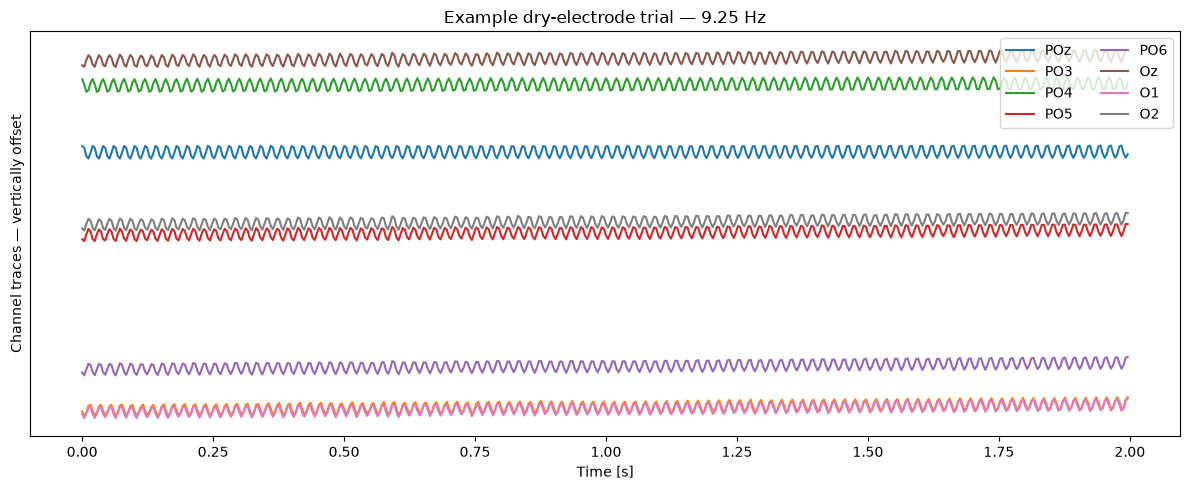

In [17]:
example_idx = 0
example_trial = X_all[example_idx]
time = np.arange(example_trial.shape[1]) / FS

plt.figure(figsize=(12, 5))

offset = 0.0
for ch_idx, channel in enumerate(CHANNELS):
    signal = example_trial[ch_idx]
    scale = np.nanstd(signal)
    if scale == 0:
        scale = 1.0
    plt.plot(time, signal / scale + offset, label=channel)
    offset += 5.0

plt.xlabel("Time [s]")
plt.ylabel("Channel traces — vertically offset")
plt.title(f"Example dry-electrode trial — {y_all[example_idx]:.2f} Hz")
plt.yticks([])
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


# 7. Preprocessing

For PSD/SNR we create a broad **5–90 Hz** filtered copy.

For CCA/FBCCA, the actual filter-bank decomposition is performed inside the classifier.

There is **no global dataset-level z-score normalization**.
`CCA(scale=True)` centers/scales variables inside each individual trial-level CCA fit,
so statistics from one participant are not reused for another participant.

The 2-s PSD uses the full 500-sample segment, giving 0.5-Hz Fourier-bin spacing,
which matches the 0.5-Hz target-frequency spacing in this dataset.


In [18]:
X_all_filtered = filter_eeg_trials(
    X_all,
    lowcut=5.0,
    highcut=90.0,
    fs=FS,
    order=4,
)

print("Raw all-subject data:", X_all.shape)
print("Filtered all-subject data:", X_all_filtered.shape)


Raw all-subject data: (12240, 8, 500)
Filtered all-subject data: (12240, 8, 500)


# 8. Spectral analysis

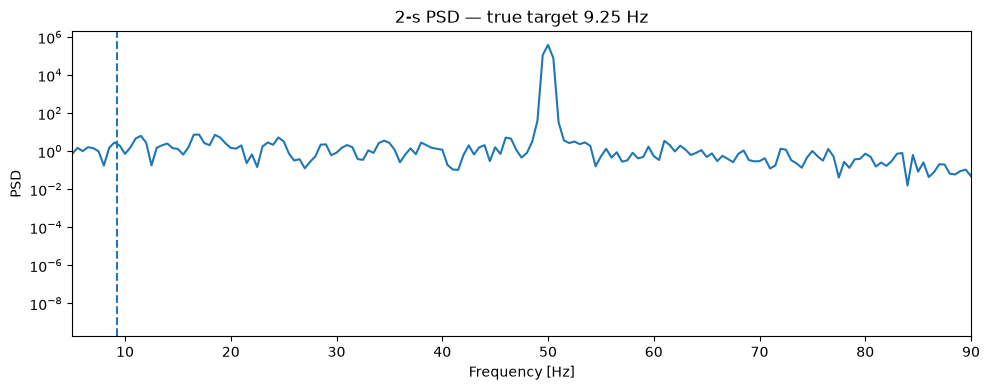

In [19]:
freqs, psd = compute_trial_mean_psd(
    X_all_filtered[example_idx],
    fs=FS,
    nperseg=X_all_filtered.shape[2],
)

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, psd)
plt.axvline(y_all[example_idx], linestyle="--")
plt.xlim(5, 90)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD")
plt.title(f"2-s PSD — true target {y_all[example_idx]:.2f} Hz")
plt.tight_layout()
plt.show()


## 8.2 Class-wise median PSD

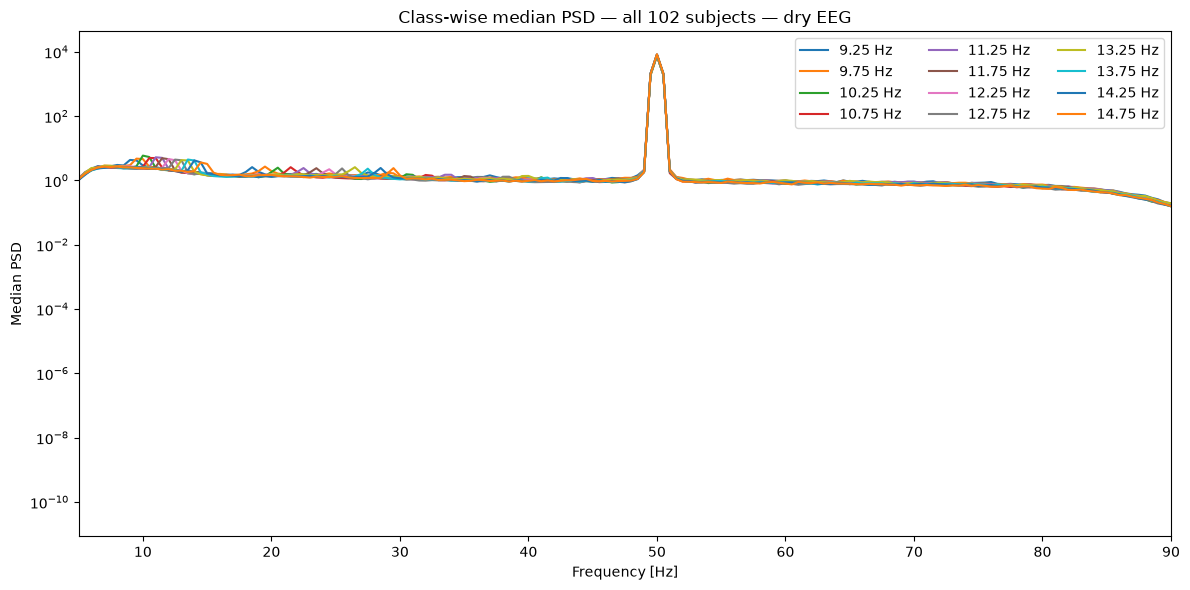

In [20]:
plt.figure(figsize=(12, 6))

for target_freq in TARGET_FREQS_ALL:
    idxs = np.where(np.isclose(y_all, target_freq))[0]

    class_psds = []
    for idx in idxs:
        f, p = compute_trial_mean_psd(
            X_all_filtered[idx],
            fs=FS,
            nperseg=X_all_filtered.shape[2],
        )
        class_psds.append(p)

    median_psd = np.median(np.vstack(class_psds), axis=0)
    plt.semilogy(f, median_psd, label=f"{target_freq:.2f} Hz")

plt.xlim(5, 90)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Median PSD")
plt.title("Class-wise median PSD — all 102 subjects — dry EEG")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


# 9. SNR analysis

In [21]:
def build_snr_dataframe(trials, true_labels, target_freqs, fs, metadata=None):
    rows = []

    for trial_idx, trial in enumerate(trials):
        freqs, trial_psd = compute_trial_mean_psd(
            trial,
            fs=fs,
            nperseg=trial.shape[1],
        )

        row = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
        }

        if metadata is not None:
            for col in ["subject", "block", "target_index"]:
                row[col] = metadata.iloc[trial_idx][col]

        for freq in target_freqs:
            snr, snr_db = compute_snr_at_freq(
                freqs,
                trial_psd,
                float(freq),
            )
            row[f"SNR_{freq:.2f}"] = snr
            row[f"SNRdB_{freq:.2f}"] = snr_db

        rows.append(row)

    out = pd.DataFrame(rows)

    score_cols = [f"SNR_{freq:.2f}" for freq in target_freqs]
    out["predicted_label"] = (
        out[score_cols]
        .idxmax(axis=1)
        .str.replace("SNR_", "", regex=False)
        .astype(float)
    )

    return out


snr_all_12 = build_snr_dataframe(
    X_all_filtered,
    y_all,
    TARGET_FREQS_ALL,
    FS,
    meta_all,
)

print_metrics(snr_all_12, "SNR baseline — 12 classes — all 102 subjects")


SNR baseline — 12 classes — all 102 subjects accuracy: 22.69%
SNR baseline — 12 classes — all 102 subjects balanced accuracy: 22.69%

              precision    recall  f1-score   support

        9.25       0.22      0.17      0.20      1020
        9.75       0.21      0.17      0.19      1020
       10.25       0.24      0.24      0.24      1020
       10.75       0.19      0.21      0.20      1020
       11.25       0.21      0.23      0.22      1020
       11.75       0.22      0.25      0.23      1020
       12.25       0.22      0.24      0.23      1020
       12.75       0.24      0.26      0.25      1020
       13.25       0.23      0.22      0.22      1020
       13.75       0.24      0.23      0.24      1020
       14.25       0.24      0.23      0.23      1020
       14.75       0.25      0.27      0.26      1020

    accuracy                           0.23     12240
   macro avg       0.23      0.23      0.23     12240
weighted avg       0.23      0.23      0.23     12240


# 10. Standard CCA baseline

In [22]:
def cca_predict(
    trials,
    true_labels,
    target_freqs,
    fs,
    filter_band=(6, 90),
    n_harmonics=5,
    metadata=None,
):
    n_samples = trials.shape[2]

    references = {
        float(freq): generate_reference_signals(
            float(freq),
            n_samples,
            fs,
            n_harmonics,
        )
        for freq in target_freqs
    }

    rows = []

    for trial_idx, trial in enumerate(trials):
        filtered = filter_trial_butter(
            trial,
            lowcut=filter_band[0],
            highcut=filter_band[1],
            fs=fs,
            order=4,
        )

        scores = {
            float(freq): get_cca_correlation(
                filtered,
                references[float(freq)],
            )
            for freq in target_freqs
        }

        pred = max(scores, key=scores.get)

        row = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(pred),
            "cca_score": float(scores[pred]),
        }

        if metadata is not None:
            for col in ["subject", "block", "target_index"]:
                row[col] = metadata.iloc[trial_idx][col]

        for freq, score in scores.items():
            row[f"CCA_{freq:.2f}"] = float(score)

        rows.append(row)

    return pd.DataFrame(rows)


cca_all_12 = cca_predict(
    X_all,
    y_all,
    TARGET_FREQS_ALL,
    FS,
    filter_band=(6, 90),
    n_harmonics=N_HARMONICS,
    metadata=meta_all,
)

print_metrics(cca_all_12, "CCA — 12 classes — all 102 subjects")


CCA — 12 classes — all 102 subjects accuracy: 64.69%
CCA — 12 classes — all 102 subjects balanced accuracy: 64.69%

              precision    recall  f1-score   support

        9.25       0.47      0.65      0.55      1020
        9.75       0.51      0.67      0.58      1020
       10.25       0.56      0.73      0.63      1020
       10.75       0.62      0.72      0.67      1020
       11.25       0.65      0.68      0.67      1020
       11.75       0.66      0.67      0.66      1020
       12.25       0.67      0.60      0.64      1020
       12.75       0.71      0.68      0.70      1020
       13.25       0.78      0.61      0.68      1020
       13.75       0.78      0.61      0.69      1020
       14.25       0.82      0.59      0.68      1020
       14.75       0.86      0.54      0.67      1020

    accuracy                           0.65     12240
   macro avg       0.68      0.65      0.65     12240
weighted avg       0.68      0.65      0.65     12240



# 11. FBCCA

In [ ]:
def fbcca_predict(
    trials,
    true_labels,
    target_freqs,
    fs,
    n_harmonics=5,
    n_subbands=5,
    a=2.0,
    b=0.25,
    metadata=None,
    show_progress=True,
):
    """Calibration-free FBCCA for Zhu2021 dry-electrode EEG.

    Each trial is classified independently:
      trial -> 5 filter-bank subbands -> CCA with each candidate frequency
            -> weighted sum of squared canonical correlations -> argmax

    No model parameters are learned from other subjects.
    """
    if n_subbands > FBCCA_N_SUBBANDS:
        raise ValueError(
            f"This notebook defines {FBCCA_N_SUBBANDS} subbands; "
            f"requested {n_subbands}."
        )

    n_samples = trials.shape[2]

    references = {
        float(freq): generate_reference_signals(
            float(freq),
            n_samples,
            fs,
            n_harmonics,
        )
        for freq in target_freqs
    }

    sos_bank = [
        design_fbcca_sos(subband_idx, fs)
        for subband_idx in range(n_subbands)
    ]

    weights = np.array([
        (idx + 1) ** (-a) + b
        for idx in range(n_subbands)
    ])

    rows = []

    iterator = enumerate(trials)

    for trial_idx, trial in iterator:
        filtered_subbands = [
            apply_sos_to_trial(trial, sos)
            for sos in sos_bank
        ]

        scores = {}

        for target_freq in target_freqs:
            rho_sq = []

            for filtered in filtered_subbands:
                rho = get_cca_correlation(
                    filtered,
                    references[float(target_freq)],
                )
                rho_sq.append(rho ** 2)

            scores[float(target_freq)] = float(
                np.dot(weights, np.asarray(rho_sq))
            )

        pred = max(scores, key=scores.get)

        row = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(pred),
            "fbcca_score": float(scores[pred]),
        }

        if metadata is not None:
            for col in ["subject", "block", "target_index"]:
                row[col] = metadata.iloc[trial_idx][col]

        for freq, score in scores.items():
            row[f"FBCCA_{freq:.2f}"] = float(score)

        rows.append(row)

    return pd.DataFrame(rows)


fbcca_all_12 = fbcca_predict(
    X_all,
    y_all,
    TARGET_FREQS_ALL,
    FS,
    n_harmonics=N_HARMONICS,
    n_subbands=FBCCA_N_SUBBANDS,
    a=FBCCA_A,
    b=FBCCA_B,
    metadata=meta_all,
)

print_metrics(
    fbcca_all_12,
    "FBCCA — 12 classes — all 102 subjects",
)

display(per_class_accuracy(fbcca_all_12))

fbcca_12_acc = safe_accuracy(fbcca_all_12)

if fbcca_12_acc < 0.30:
    warnings.warn(
        "12-class FBCCA is unexpectedly low for this dataset. "
        "Re-check that the corrected target-index mapping is being used "
        "and that the notebook was restarted and run from the top."
    )


## 11.1 Synthetic sanity check

Before processing the real dataset, this small test verifies that the FBCCA implementation
can recover known sinusoidal SSVEP frequencies. It is **not** a scientific result; it is only
a code-level sanity check.


In [20]:
def run_synthetic_fbcca_sanity_check(seed=42):
    rng = np.random.default_rng(seed)
    n_samples = int(STIM_DURATION_SEC * FS)
    t = np.arange(n_samples) / FS

    synthetic_trials = []
    synthetic_labels = []

    for freq in TARGET_FREQS_ALL:
        channels = []

        for ch_idx in range(len(CHANNELS)):
            phase = rng.uniform(0, 2 * np.pi)

            signal = (
                1.0 * np.sin(2 * np.pi * freq * t + phase)
                + 0.45 * np.sin(2 * np.pi * 2 * freq * t + 0.3 * phase)
                + 0.20 * np.sin(2 * np.pi * 3 * freq * t + 0.6 * phase)
                + 0.20 * rng.standard_normal(n_samples)
            )

            channels.append(signal)

        synthetic_trials.append(np.vstack(channels))
        synthetic_labels.append(freq)

    synthetic_trials = np.stack(synthetic_trials)
    synthetic_labels = np.asarray(synthetic_labels)

    result = fbcca_predict(
        synthetic_trials,
        synthetic_labels,
        TARGET_FREQS_ALL,
        FS,
        n_harmonics=N_HARMONICS,
        n_subbands=FBCCA_N_SUBBANDS,
        a=FBCCA_A,
        b=FBCCA_B,
    )

    acc = safe_accuracy(result)
    print(f"Synthetic FBCCA sanity-check accuracy: {acc:.2%}")

    if acc < 0.90:
        raise RuntimeError(
            "Synthetic FBCCA sanity check failed. "
            "Do not interpret real-data results until the implementation is fixed."
        )

    return result


synthetic_fbcca_result = run_synthetic_fbcca_sanity_check()


Synthetic FBCCA sanity-check accuracy: 100.00%


# 12. Selecting the 4 best distinguishable classes across all 102 subjects

For every one of the **495 possible four-class subsets**, the notebook:

1. keeps trials belonging to those four true classes from all 102 subjects,
2. uses only the FBCCA scores of those four candidate frequencies,
3. re-predicts each trial among those four classes,
4. computes accuracy and balanced accuracy,
5. ranks all subsets.

The top-ranked subset is the set of four frequencies that is easiest for this FBCCA pipeline
to distinguish **on the complete Zhu2021 dry-electrode dataset**.

Because the same participants are used both for class selection and reporting the final score,
treat the result as a descriptive full-dataset result rather than an independent held-out estimate.


In [21]:
def evaluate_four_class_subset(fbcca_score_df, subset):
    subset = tuple(float(x) for x in subset)

    mask = fbcca_score_df["true_label"].astype(float).isin(subset)
    df = fbcca_score_df.loc[mask].copy()

    score_cols = [f"FBCCA_{freq:.2f}" for freq in subset]
    score_matrix = df[score_cols].to_numpy()

    pred_idx = np.argmax(score_matrix, axis=1)
    preds = np.asarray(subset, dtype=float)[pred_idx]

    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(preds)

    spacing = min(
        abs(a - b)
        for i, a in enumerate(subset)
        for b in subset[i + 1:]
    )

    return {
        "frequencies": subset,
        "min_spacing_hz": spacing,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "n_trials": len(df),
    }


subset_results = pd.DataFrame([
    evaluate_four_class_subset(fbcca_all_12, subset)
    for subset in combinations(TARGET_FREQS_ALL, 4)
])

subset_results = subset_results.sort_values(
    ["balanced_accuracy", "accuracy", "min_spacing_hz"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(subset_results.head(20))


,frequencies,min_spacing_hz,accuracy,balanced_accuracy,n_trials
0,"(10.25, 13.75, 14.25, 14.75)",0.5,0.814706,0.814706,4080
1,"(10.25, 12.75, 14.25, 14.75)",0.5,0.810294,0.810294,4080
2,"(10.25, 12.75, 13.75, 14.25)",0.5,0.807108,0.807108,4080
3,"(10.25, 11.25, 14.25, 14.75)",0.5,0.805882,0.805882,4080
4,"(10.25, 13.25, 14.25, 14.75)",0.5,0.805147,0.805147,4080
5,"(10.25, 10.75, 14.25, 14.75)",0.5,0.804902,0.804902,4080
6,"(13.25, 13.75, 14.25, 14.75)",0.5,0.804902,0.804902,4080
7,"(10.25, 12.75, 13.75, 14.75)",1.0,0.804167,0.804167,4080
8,"(10.25, 10.75, 12.75, 14.25)",0.5,0.803431,0.803431,4080
9,"(10.25, 10.75, 13.75, 14.25)",0.5,0.802941,0.802941,4080


## 12.2 Selected frequencies

In [22]:
SELECTED_4_FREQS = list(subset_results.iloc[0]["frequencies"])

print("Selected 4 frequencies:", SELECTED_4_FREQS)
print(
    "All-subject balanced accuracy used for class selection:",
    f"{subset_results.iloc[0]['balanced_accuracy']:.2%}"
)


Selected 4 frequencies: [10.25, 13.75, 14.25, 14.75]
All-subject balanced accuracy used for class selection: 81.47%


## 12.3 Diagnostics for the selected four classes

In [23]:
selected_diagnostics = pd.DataFrame({
    "frequency": SELECTED_4_FREQS,
    "12class_FBCCA_accuracy_all102": [
        np.mean(
            np.isclose(
                fbcca_all_12.loc[
                    np.isclose(fbcca_all_12["true_label"], freq),
                    "predicted_label",
                ],
                freq,
                atol=0.01,
            )
        )
        for freq in SELECTED_4_FREQS
    ],
    "median_SNR_dB_all102": [
        snr_all_12.loc[
            np.isclose(snr_all_12["true_label"], freq),
            f"SNRdB_{freq:.2f}",
        ].median()
        for freq in SELECTED_4_FREQS
    ],
})

display(selected_diagnostics)


,frequency,12class_FBCCA_accuracy_all102,median_SNR_dB_all102
0,10.25,0.724510,2.493246
1,13.75,0.671569,2.716820
2,14.25,0.707843,2.700875
3,14.75,0.684314,2.132928


# 13. Final 4-class FBCCA on all 102 subjects

In [24]:
all_4_mask = np.isin(y_all, SELECTED_4_FREQS)

X_all_4 = X_all[all_4_mask]
y_all_4 = y_all[all_4_mask]
meta_all_4 = meta_all.loc[all_4_mask].reset_index(drop=True)

print("4-class trials:", len(y_all_4))
print("Subjects:", meta_all_4["subject"].nunique())
print("Selected classes:", SELECTED_4_FREQS)

assert meta_all_4["subject"].nunique() == 102
assert len(y_all_4) == 102 * 10 * 4


4-class trials: 4080
Subjects: 102
Selected classes: [10.25, 13.75, 14.25, 14.75]


In [ ]:
fbcca_all_4 = fbcca_predict(
    X_all_4,
    y_all_4,
    SELECTED_4_FREQS,
    FS,
    n_harmonics=N_HARMONICS,
    n_subbands=FBCCA_N_SUBBANDS,
    a=FBCCA_A,
    b=FBCCA_B,
    metadata=meta_all_4,
)

print_metrics(
    fbcca_all_4,
    "FINAL FBCCA — 4 classes — all 102 subjects",
)
display(per_class_accuracy(fbcca_all_4))


In [ ]:
plot_confusion(
    fbcca_all_4,
    "Zhu2021 dry EEG — all 102 subjects — 4-class FBCCA",
)


## 13.4 Subject-level robustness across all 102 participants

In [ ]:
subject_accuracy = (
    fbcca_all_4
    .assign(
        correct=lambda d: np.isclose(
            d["true_label"].astype(float),
            d["predicted_label"].astype(float),
            atol=0.01,
        )
    )
    .groupby("subject")["correct"]
    .mean()
    .sort_values(ascending=False)
)

display(subject_accuracy.to_frame("accuracy"))

print("Number of evaluated subjects:", len(subject_accuracy))
print("Mean subject accuracy:", f"{subject_accuracy.mean():.2%}")
print("Median subject accuracy:", f"{subject_accuracy.median():.2%}")
print("Worst subject accuracy:", f"{subject_accuracy.min():.2%}")
print("Best subject accuracy:", f"{subject_accuracy.max():.2%}")


# 14. CCA vs FBCCA on the same all-subject 4-class problem

In [ ]:
cca_all_4 = cca_predict(
    X_all_4,
    y_all_4,
    SELECTED_4_FREQS,
    FS,
    filter_band=(6, 90),
    n_harmonics=N_HARMONICS,
    metadata=meta_all_4,
)

comparison = pd.DataFrame({
    "model": ["CCA", "FBCCA"],
    "accuracy": [
        safe_accuracy(cca_all_4),
        safe_accuracy(fbcca_all_4),
    ],
    "balanced_accuracy": [
        safe_balanced_accuracy(cca_all_4),
        safe_balanced_accuracy(fbcca_all_4),
    ],
})

display(comparison)


# 15. Interpretation

This corrected notebook evaluates **all 102 participants** with dry electrodes.

The main corrections are:

1. the `.mat` target index now uses the official target order,
2. FBCCA uses 5 harmonics,
3. FBCCA uses 5 M3-style filter-bank subbands,
4. dry-electrode weighting uses `a = 2`, `b = 0.25`,
5. the analysis retains frequencies up to 90 Hz so useful harmonics are not cut at 45 Hz,
6. PSD uses the full 2-s segment, giving 0.5-Hz bin spacing.

The final 4-class score should be described as:

> **4-class calibration-free FBCCA performance across all 102 Zhu2021 dry-electrode subjects,
> where the four target frequencies were selected as the most distinguishable subset on that
> same complete dataset.**

FBCCA itself does not learn a cross-subject model. CCA scaling is fitted independently
inside each trial/subband comparison.

## Limitation

The same 102 subjects are used both to select the easiest four classes and to report their
final accuracy. Therefore that final 4-class number is descriptive and can be somewhat
optimistic for a completely new cohort.

For deployment, keep the selected four frequencies fixed and validate them on newly recorded
TaaLON users without re-selecting the frequencies.


# 16. References

1. Zhu F., Jiang L., Dong G., Gao X., Wang Y.  
   **An Open Dataset for Wearable SSVEP-Based Brain-Computer Interfaces.**  
   *Sensors*. 2021;21(4):1256.  
   https://doi.org/10.3390/s21041256

2. Official Zhu2021 dataset README:  
   https://bci.med.tsinghua.edu.cn/upload/zhufangkun/Readme.pdf

3. Official target-frequency / phase mapping:  
   https://bci.med.tsinghua.edu.cn/upload/zhufangkun/stimulation_information.pdf

4. Figshare dataset:  
   https://figshare.com/articles/dataset/An_Open_Dataset_for_Wearable_SSVEP-Based_Brain-Computer_Interfaces/13560281

5. Chen X. et al.  
   **Filter bank canonical correlation analysis for implementing a high-speed SSVEP-based BCI.**  
   *Journal of Neural Engineering*. 2015;12(4):046008.  
   https://doi.org/10.1088/1741-2560/12/4/046008
